# SR3 RV Lab — Framework 1: the skew basis (risk-reversal spread across expiries)

**RV class: A/B — within-contract shape, coupled across two expiries.**

The traded object is a 4-leg package: long the back contract's risk reversal
(long hike wing = put on price, short cut wing = call on price) against short
the front contract's risk reversal, with all four strikes fixed on the
execution date at the listed strikes nearest `forward ± offset`.

`signal = RR_back - RR_front` in bp of listed settle premium. This is the same
object the P&L is marked on — signal and mark are one executable structure, so
there is no model-vs-market wedge to fool us.

Why this is not pinned by parity: put-call parity fixes `C - P` at a common
strike to `F - K`. It says nothing about the *difference between two different
strikes' premiums* (that is the skew), and nothing about how that difference
compares across two expiries. The level of the RR spread is genuinely free.

Honesty rules in force: listed marks only, lag-1 fills, entry gates on BL
surface quality, costs charged per completed trade, and both signs tested.

In [1]:
CONFIG = dict(
    wing_offset=0.375,        # percent from the forward to each wing
    strike_tol=0.13,          # max distance from the target strike (percent)
    min_oi=100,               # per-leg open-interest floor for strike selection
    pair_gaps=(1, 2),         # 1 = adjacent quarterlies, 2 = 6-month pairs
    contracts_per_leg=100,    # package size for the dollar column
    cost_bp=2.5,              # headline round-trip cost on the package
    zscore_windows=(60, 120),
    mas=(1, 5, 10),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    entry_every=(1, 5),       # 1 = daily, 5 = weekly rebalance
)
CONFIG

{'wing_offset': 0.375,
 'strike_tol': 0.13,
 'min_oi': 100,
 'pair_gaps': (1, 2),
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'zscore_windows': (60, 120),
 'mas': (1, 5, 10),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'entry_every': (1, 5)}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import (
    LabConfig, config_from_row, coverage_report, cost_block, exit_comparison,
    gate_sensitivity, grid_block, header_block, league_row, load_lab,
    marks_x_lag_panel, median_row, stability_block, three_panel_equity,
)
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, grid_search, pair_rr_basis,
    risk_reversal_panel, run_backtest,
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

lab = load_lab()
print(coverage_report(lab).to_string())

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


            first       last  days  gate_ok  med_resid  quotes
symbol                                                        
SFRH25 2024-07-01 2025-03-13   177    0.548      1.018   21952
SFRH26 2024-07-01 2026-03-12   427    0.293      3.509   43682
SFRM25 2024-07-01 2025-06-12   240    0.404      1.976   26908
SFRM26 2024-07-01 2026-06-11   490    0.259      3.951   48048
SFRU25 2024-07-01 2025-09-11   302    0.344      2.748   33814
SFRZ25 2024-07-01 2025-12-11   366    0.374      3.381   39412
SFRU26 2024-09-18 2026-07-28   485    0.293      5.511   46212
SFRZ26 2024-12-18 2026-07-28   402    0.276      6.139   36952
SFRH27 2025-03-19 2026-07-28   341    0.279      4.527   29720
SFRM27 2025-06-18 2026-07-28   290    0.262      6.221   23938
SFRU27 2025-09-17 2026-07-28   225    0.316      3.688   18222
SFRZ27 2025-12-17 2026-07-28   160    0.206      7.643   12404
SFRH28 2026-03-18 2026-07-28    95    0.179      6.680    6924
SFRM28 2026-06-17 2026-07-28    30    0.000     21.414 

## Signal panel

One row per (adjacent pair, date): the premium-native RR spread plus the four
strikes that produced it, and the AND of both legs' BL quality gates.

In [3]:
rr = risk_reversal_panel(lab["quotes"], lab["contracts"],
                         offset=CONFIG["wing_offset"], tol=CONFIG["strike_tol"],
                         min_oi=CONFIG["min_oi"])
basis = pair_rr_basis(rr, quality=lab["gate"], gaps=CONFIG["pair_gaps"])
basis = add_event_distance(basis)
print(f"pairs ({basis['key'].nunique()}): {sorted(basis['key'].unique())}")
print(f"rows: {len(basis)}   leg gate: {basis['gate'].mean():.1%}   "
      f"BL gate: {basis['gate_bl'].mean():.1%}")
print(basis.groupby("key")["signal"].describe().round(2).to_string())

pairs (25): ['SFRH25-SFRM25', 'SFRH25-SFRU25', 'SFRH26-SFRM26', 'SFRH26-SFRU26', 'SFRH27-SFRM27', 'SFRH27-SFRU27', 'SFRH28-SFRM28', 'SFRM25-SFRU25', 'SFRM25-SFRZ25', 'SFRM26-SFRU26', 'SFRM26-SFRZ26', 'SFRM27-SFRU27', 'SFRM27-SFRZ27', 'SFRU25-SFRH26', 'SFRU25-SFRZ25', 'SFRU26-SFRH27', 'SFRU26-SFRZ26', 'SFRU27-SFRH28', 'SFRU27-SFRZ27', 'SFRZ25-SFRH26', 'SFRZ25-SFRM26', 'SFRZ26-SFRH27', 'SFRZ26-SFRM27', 'SFRZ27-SFRH28', 'SFRZ27-SFRM28']
rows: 6178   leg gate: 100.0%   BL gate: 10.9%
               count  mean   std    min   25%   50%   75%    max
key                                                             
SFRH25-SFRM25  177.0 -1.37  2.67  -7.75 -3.50 -1.50  0.75   5.50
SFRH25-SFRU25  177.0 -1.06  4.18  -9.50 -4.50 -1.00  2.25   8.50
SFRH26-SFRM26  406.0  0.35  3.28  -6.75 -2.25 -0.25  2.00   9.25
SFRH26-SFRU26  357.0  0.61  4.41 -11.25 -2.75  0.25  4.00  10.50
SFRH27-SFRM27  227.0  1.26  2.85  -6.00 -1.25  1.75  3.25   7.00
SFRH27-SFRU27  209.0  1.94  3.37  -4.50 -0.50  1.25  4.75  1

### Model-mark comparison series (for the honesty panel only)

The BL mean-minus-median skew basis, `mm_back - mm_front`. Prior work measured
its P&L as *anti*-correlated with the executable one; it is carried here purely
so the marks x lag panel can show that again on this sample.

In [4]:
c = lab["contracts"]
mm = c.set_index(["as_of", "symbol"])["mm_bp"]
model_rows = []
for key, sub in basis.groupby("key"):
    f, b = key.split("-")
    mf = mm.reindex(pd.MultiIndex.from_arrays([sub["as_of"], [f] * len(sub)]))
    mb = mm.reindex(pd.MultiIndex.from_arrays([sub["as_of"], [b] * len(sub)]))
    m = sub.copy()
    m["signal"] = (mb.to_numpy() - mf.to_numpy())
    model_rows.append(m)
model_basis = pd.concat(model_rows, ignore_index=True).dropna(subset=["signal"])
print(f"model-mark signal rows: {len(model_basis)}")

model-mark signal rows: 6178


## The tradeable package

Strikes are read off the signal frame at the **execution** date, so the entry
never uses a strike chosen with information from the signal bar.

In [5]:
BASIS_IDX = basis.set_index(["key", "as_of"]).sort_index()


def builder(key, exec_date, direction):
    try:
        r = BASIS_IDX.loc[(key, exec_date)]
    except KeyError:
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    front, back = key.split("-")
    return Structure((
        Leg("option", back, 1.0, "P", float(r["hk_K_b"])),
        Leg("option", back, -1.0, "C", float(r["ct_K_b"])),
        Leg("option", front, -1.0, "P", float(r["hk_K_f"])),
        Leg("option", front, 1.0, "C", float(r["ct_K_f"])),
    ), label=f"RRspread {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 quality_gate=True)

## Grid — both directions, full sweep

The distribution comes first; the top rows are selection-inflated by
construction and are shown only after it.

In [6]:
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style",
          "entry_every"]
grid = grid_search(
    {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
     "zscore_window": list(CONFIG["zscore_windows"]),
     "entry_min_zscore": list(CONFIG["entry_zs"]),
     "exit_style": list(CONFIG["exits"]),
     "entry_every": list(CONFIG["entry_every"])},
    signals=basis, book=lab["book"], builder=builder, base=BASE,
    show_progress=True)
print(f"\n{len(grid)} configs, {int(grid['n_trades'].sum())} trades in total")

  25/216 configs


  50/216 configs


  75/216 configs


  100/216 configs


  125/216 configs


  150/216 configs


  175/216 configs


  200/216 configs



216 configs, 19664 trades in total


In [7]:
best = grid_block(grid, PARAMS)
_ = stability_block(grid, best, PARAMS)

  216 configs | median -181.00bp | IQR [-328.12, -71.44] | 5% net-positive | best +29.50bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  entry_every  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10            120               2.5         z0            5        20     0.350       1.475         29.50        73750.0   0.677     -33.50
     fade  10            120               2.5       half            5        20     0.350       1.300         26.00        65000.0   0.639     -36.25
     fade   5            120               2.5         z0            5        16     0.188       0.922         14.75        36875.0   0.477     -34.25
     fade   1             60               2.5         z0            5         2     0.500       7.000         14.00        35000.0   3.345      -6.75
     fade   5            120               2.5       half            5        16    

### Which sign wins?

The house rule: never assume mean-reversion. If momentum's distribution is
better than fade's, that is the finding.

In [8]:
sign_test = (grid.groupby("direction")
             .agg(n_configs=("total_net_bp", "size"),
                  median_net_bp=("total_net_bp", "median"),
                  pct_positive=("total_net_bp", lambda s: (s > 0).mean()),
                  best_net_bp=("total_net_bp", "max"),
                  median_trades=("n_trades", "median"))
             .round(3))
print(sign_test.to_string())

           n_configs  median_net_bp  pct_positive  best_net_bp  median_trades
direction                                                                    
fade             108       -148.250         0.093         29.5           70.5
momentum         108       -226.125         0.000        -13.0           70.5


## Best honest config

Skew basis — best config  |  fade|ma10|w120|z2.5|z0|lag1|every5  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades    20   skipped    0   hit 35%   avg +1.475bp   avg hold 17.8d   stale 0.0%
  total     +29.50bp   $     +73,750   gross +79.50bp
  daily-MTM Sharpe +0.68   maxDD -33.50bp ($-83,750)   worst trade -12.00bp
  t(trade) +0.63   NW t(daily) +0.69   non-overlap SR +0.16   DSR p=0.000 over 216 trials


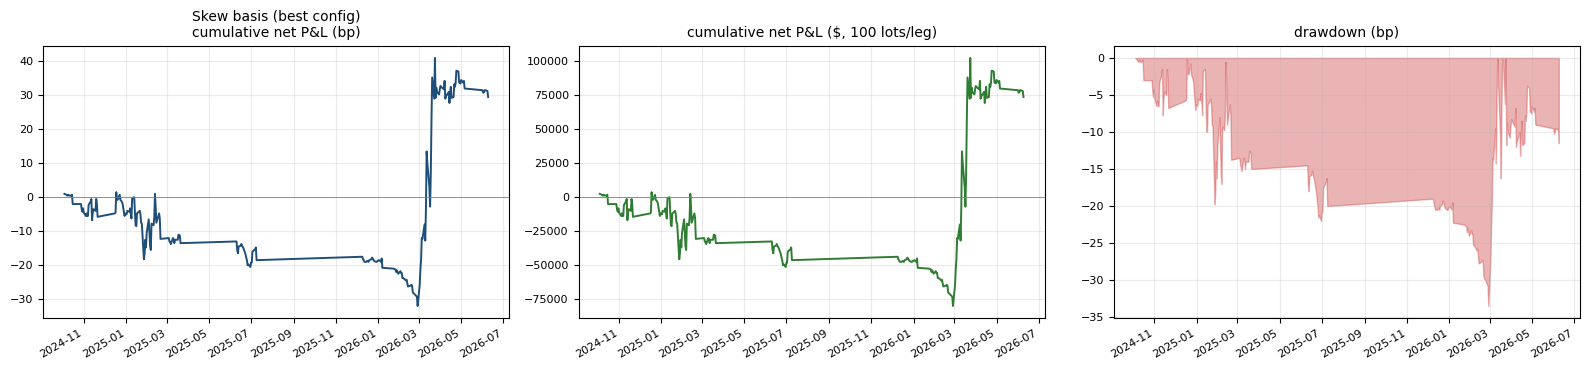

In [9]:
best_cfg = config_from_row(BASE, best, PARAMS)
res = run_backtest(best_cfg, signals=basis, book=lab["book"], builder=builder)
_ = header_block("Skew basis — best config", res, grid=grid)
fig = three_panel_equity(res, "Skew basis (best config)")
plt.show()

In [10]:
if not res.trades.empty:
    print(res.trades.sort_values("entry").to_string(index=False))

          key  dir              structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp  net_usd  stale_frac  pkg_contracts    exit_reason
SFRZ25-SFRH26   -1 RRspread SFRZ25-SFRH26  2024-10-02 2024-10-03 2024-10-16     9  2.603      0.50      2.5   -2.00  -5000.0         0.0            4.0 mean_reversion
SFRH25-SFRM25    1 RRspread SFRH25-SFRM25  2024-10-23 2024-10-24 2024-11-21    20 -2.958     10.75      2.5    8.25  20625.0         0.0            4.0       max_hold
SFRM25-SFRZ25   -1 RRspread SFRM25-SFRZ25  2024-10-23 2024-10-24 2024-11-21    20  2.706     -9.50      2.5  -12.00 -30000.0         0.0            4.0       max_hold
SFRH25-SFRU25    1 RRspread SFRH25-SFRU25  2024-12-12 2024-12-13 2025-01-14    20 -2.655      5.00      2.5    2.50   6250.0         0.0            4.0       max_hold
SFRH25-SFRM25    1 RRspread SFRH25-SFRM25  2025-01-06 2025-01-07 2025-02-05    20 -2.643      0.50      2.5   -2.00  -5000.0         0.0            4.0       max_hol

## Honesty panels

In [11]:
print("EXIT COMPARISON")
print(exit_comparison(best_cfg, signals=basis, book=lab["book"],
                      builder=builder).to_string(index=False))

EXIT COMPARISON


exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        20     0.350       1.475         29.50        73750.0   0.677     -33.50          17.75
half        20     0.350       1.300         26.00        65000.0   0.639     -36.25          16.90
  t5        27     0.259      -2.009        -54.25      -135625.0  -3.613     -61.75           5.00
 t10        23     0.217      -2.478        -57.00      -142500.0  -2.390     -70.00          10.00
 t20        20     0.450       1.412         28.25        70625.0   0.590     -33.75          20.00


In [12]:
print("MARKS x LAG (same structure, same listed P&L marks — only the signal "
      "source and the fill lag change)")
mxl = marks_x_lag_panel(best_cfg, signals=basis, book=lab["book"],
                        builder=builder, model_signals=model_basis)
print(mxl.to_string(index=False))
if "lag_inflation" in mxl.attrs:
    print(f"\nsame-bar (lag 0) gross inflation: {mxl.attrs['lag_inflation']:.1%}")

MARKS x LAG (same structure, same listed P&L marks — only the signal source and the fill lag change)


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        20           82.75         32.75   0.773     0.300
       listed    1        20           79.50         29.50   0.677     0.350
        model    0        22            5.50        -49.50  -1.474     0.227
        model    1        22            1.75        -53.25  -1.663     0.318

same-bar (lag 0) gross inflation: 3.9%


In [13]:
_ = cost_block(res)


  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 20          79.5       3.975      0.65       198750.0
           0.5 20          69.5       3.475      0.50       173750.0
           1.0 20          59.5       2.975      0.50       148750.0
           1.5 20          49.5       2.475      0.45       123750.0
           2.5 20          29.5       1.475      0.35        73750.0
           4.0 20          -0.5      -0.025      0.30        -1250.0


### What each entry gate costs

`gate` is leg-level (both wings listed and OI-screened). `gate_bl` is the
stricter Breeden-Litzenberger surface rule from the spec. On this panel the BL
rule mostly rejects days when the listed chain is too narrow for the density to
integrate to one (`pre_norm_mass` sits *below* 1, i.e. truncation) rather than
days when the two traded wings are stale — so it is reported, not assumed.

In [14]:
print(gate_sensitivity(best_cfg, signals=basis, book=lab["book"],
                       builder=builder).to_string(index=False))

   gate  pass_rate  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
   none      1.000        20      0.35       1.475          29.5        73750.0   0.677     -33.50
   gate      1.000        20      0.35       1.475          29.5        73750.0   0.677     -33.50
gate_bl      0.109         4      0.25      -7.000         -28.0       -70000.0  -2.550     -38.25
    all      0.109         4      0.25      -7.000         -28.0       -70000.0  -2.550     -38.25


## Variant: FOMC event-window entries only

Enter only in the five business days before a meeting; everything else is
unchanged. This tests whether the basis carries event information rather than
a permanent premium.

In [15]:
ev = basis.copy()
ev["eligible"] = ev["days_to_fomc"].between(-7, -1)
print(f"eligible bars: {ev['eligible'].mean():.1%}")
grid_ev = grid_search(
    {"direction": list(CONFIG["directions"]), "ma": [1, 5],
     "entry_min_zscore": [1.0, 1.5, 2.0], "exit_style": ["t5", "t10", "z0"]},
    signals=ev, book=lab["book"], builder=builder, base=BASE)
best_ev = grid_block(grid_ev, ["direction", "ma", "entry_min_zscore", "exit_style"])

eligible bars: 16.0%


  36 configs | median -172.00bp | IQR [-229.88, -69.62] | 0% net-positive | best -29.25bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade   1               2.0         z0        16     0.125      -1.828        -29.25       -73125.0  -1.983     -30.00
     fade   1               2.0         t5        16     0.125      -1.859        -29.75       -74375.0  -3.509     -32.00
 momentum   5               2.0        t10        27     0.259      -1.139        -30.75       -76875.0  -1.059     -32.75
 momentum   1               2.0        t10        16     0.125      -2.359        -37.75       -94375.0  -2.657     -40.75
     fade   1               2.0        t10        16     0.188      -2.641        -42.25      -105625.0  -2.796     -44.50
 momentum   5               2.0         z0        27     0.259      -1.565        -42.25      -105625.

Skew basis — FOMC window  |  fade|ma1|w120|z2.0|z0|lag1|every1  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades    16   skipped    0   hit 12%   avg -1.828bp   avg hold 8.2d   stale 0.7%
  total     -29.25bp   $     -73,125   gross +10.75bp
  daily-MTM Sharpe -1.98   maxDD -30.00bp ($-75,000)   worst trade -5.00bp
  t(trade) -3.53   NW t(daily) -1.29   non-overlap SR -0.73   DSR p=0.000 over 36 trials


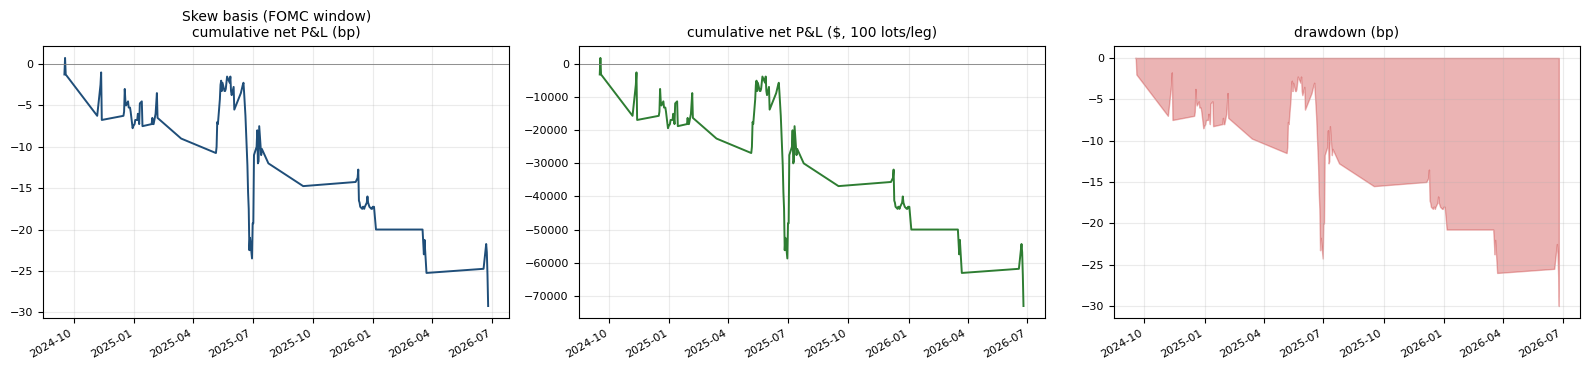

In [16]:
res_ev = run_backtest(
    config_from_row(BASE, best_ev, ["direction", "ma", "entry_min_zscore",
                                    "exit_style"]),
    signals=ev, book=lab["book"], builder=builder)
_ = header_block("Skew basis — FOMC window", res_ev, grid=grid_ev)
if not res_ev.daily_bp.empty:
    fig = three_panel_equity(res_ev, "Skew basis (FOMC window)")
    plt.show()

## Delta-hedged variant

The 4-leg risk-reversal spread is not delta-neutral: the two contracts' wings
do not cancel. Killing each contract's delta daily on its own future isolates
the skew content from the residual direction, exactly as in the digital
calendar. If the edge disappears here, it was direction.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -279.06bp | IQR [-521.74, -113.30] | 0% net-positive | best -22.19bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1            120               2.5        t10         9     0.000      -2.466       -22.191      -55476.25  -4.603    -22.223
     fade   1            120               2.5         z0        11     0.091      -2.606       -28.666      -71665.00  -5.540    -28.291
     fade   1            120               2.5        t10         9     0.000      -3.214       -28.923      -72308.25  -6.299    -28.986
     fade   1            120               2.5       half        11     0.091      -2.658       -29.238      -73095.00  -5.891    -26.363
 momentum   1            120               2.5       half        11     0.000      -3.035       -33.380      -83451.25  -6.654    -30.528
 momentum 

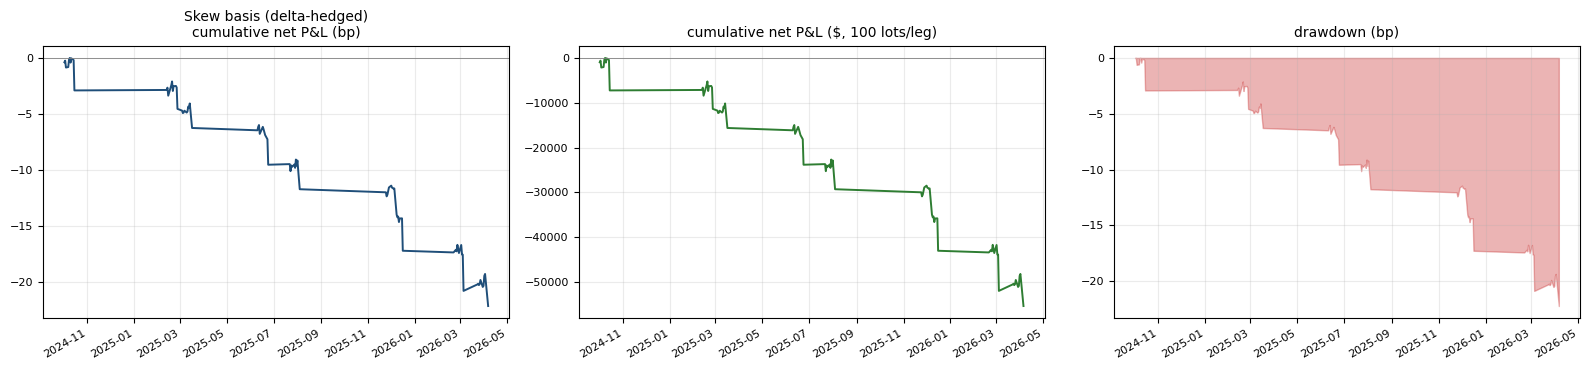

In [17]:
BASE_HEDGED = dataclasses.replace(BASE, delta_hedge="daily", future_leg_bp=0.25)
grid_h = grid_search(
    {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
     "zscore_window": list(CONFIG["zscore_windows"]),
     "entry_min_zscore": list(CONFIG["entry_zs"]),
     "exit_style": list(CONFIG["exits"])},
    signals=basis, book=lab["book"], builder=builder, base=BASE_HEDGED,
    show_progress=True)
PARAMS_H = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]
best_h = grid_block(grid_h, PARAMS_H)
res_h = run_backtest(config_from_row(BASE_HEDGED, best_h, PARAMS_H),
                     signals=basis, book=lab["book"], builder=builder)
_ = header_block("Skew basis — delta-hedged", res_h, grid=grid_h)
if not res_h.daily_bp.empty:
    fig = three_panel_equity(res_h, "Skew basis (delta-hedged)")
    plt.show()

In [18]:
print("\nUNHEDGED vs DELTA-HEDGED — is the edge skew or direction?")
print(pd.DataFrame([
    {"variant": "unhedged", "median_net_bp": grid["total_net_bp"].median(),
     "best_net_bp": grid["total_net_bp"].max(),
     "pct_positive": float((grid["total_net_bp"] > 0).mean())},
    {"variant": "delta-hedged", "median_net_bp": grid_h["total_net_bp"].median(),
     "best_net_bp": grid_h["total_net_bp"].max(),
     "pct_positive": float((grid_h["total_net_bp"] > 0).mean())},
]).round(2).to_string(index=False))


UNHEDGED vs DELTA-HEDGED — is the edge skew or direction?
     variant  median_net_bp  best_net_bp  pct_positive
    unhedged        -181.00        29.50          0.05
delta-hedged        -279.06       -22.19          0.00


## League rows

Two rows per framework: the best honest config and the *median* config of the
sweep. If only the first is positive, the framework is a selection artifact.

In [19]:
med = median_row(grid)
res_med = run_backtest(config_from_row(BASE, med, PARAMS), signals=basis,
                       book=lab["book"], builder=builder)
_ = header_block("Skew basis — median config", res_med, grid=grid)

Skew basis — median config  |  fade|ma1|w120|z2.0|half|lag1|every1  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades    87   skipped    0   hit 9%   avg -2.034bp   avg hold 5.7d   stale 0.3%
  total    -177.00bp   $    -442,500   gross +40.50bp
  daily-MTM Sharpe -3.27   maxDD -178.25bp ($-445,625)   worst trade -13.25bp
  t(trade) -4.68   NW t(daily) -3.65   non-overlap SR -0.75   DSR p=0.000 over 216 trials


In [20]:
league_row("1. Skew basis (RR spread)", "best-config", res, grid=grid, cls="A/B",
           note=f"{CONFIG['wing_offset']*100:.0f}bp wings, 4 option legs")
league_row("1. Skew basis (RR spread)", "median-config", res_med, grid=grid,
           cls="A/B", note="median of the sweep, not selected")
league_row("1. Skew basis (RR spread)", "fomc-window", res_ev, grid=grid_ev,
           cls="A/B", note="entries limited to 7 business days pre-FOMC")
league_row("1b. Skew basis (delta-hedged)", "best-config", res_h, grid=grid_h,
           cls="A/B", note="each contract's delta re-hedged daily — skew only")


  LEAGUE ROW  1. Skew basis (RR spread) / best-config: SELECTION-ARTIFACT  (taker +29.50bp, maker +79.50bp, DSR p=0.000)

  LEAGUE ROW  1. Skew basis (RR spread) / median-config: MARGINAL-maker-only  (taker -177.00bp, maker +40.50bp, DSR p=0.000)

  LEAGUE ROW  1. Skew basis (RR spread) / fomc-window: MARGINAL-maker-only  (taker -29.25bp, maker +10.75bp, DSR p=0.000)

  LEAGUE ROW  1b. Skew basis (delta-hedged) / best-config: DEAD (too few trades)  (taker -22.19bp, maker +0.31bp, DSR p=0.000)


{'framework': '1b. Skew basis (delta-hedged)',
 'variant': 'best-config',
 'class': 'A/B',
 'config': 'momentum|ma1|w120|z2.5|t10|lag1|every1|dh',
 'n_trades': 9,
 'hit_rate': 0.0,
 'avg_net_bp': -2.4656111111111114,
 'total_gross_bp': 0.3094999999999999,
 'total_net_bp': -22.190500000000004,
 'total_net_usd': -55476.25000000001,
 'net_bp_maker': 0.3094999999999999,
 'net_bp_taker': -22.190500000000004,
 'net_usd_taker': -55476.25000000001,
 'sharpe': -4.602640818950134,
 'max_dd_bp': -22.223496066380385,
 'max_dd_usd': -55558.74016595096,
 'avg_hold_days': 10.0,
 'dsr_prob': 6.695032878646875e-14,
 'grid_median_net_bp': -279.0625,
 'nonoverlap_sharpe': -2.929165839144344,
 'verdict': 'DEAD (too few trades)',
 'note': "each contract's delta re-hedged daily — skew only"}